# 4. 多层感知机 (MLP)

In [2]:
# 本章开始，会调用曾经的函数。
# 1. 开启自动重载
# %load_ext autoreload: 加载“自动重载”这个扩展插件。
# %autoreload 2: 设置重载模式为 模式 2。
# 模式说明：
#     %autoreload 0：禁用自动重载（默认状态）。
#     %autoreload 1：只重载那些用 %aimport 指定的模块。
#     %autoreload 2：最强模式。在你每次执行任何 Notebook 单元格之前，它都会自动检查所有已导入的模块。如果发现文件变了，它就立刻在内存里替换掉旧的代码。
%load_ext autoreload
%autoreload 2

# 2. 导入工具包
import d2l_utils as d2l

# 3. 验证
print(f"D2L Utils Version: {d2l.__version__}")
print(f"D2L Utils All: {d2l.__all__}")

D2L Utils Version: 0.1.0
D2L Utils All: ['DATA_ROOT', 'IS_WINDOWS', 'Accumulator', 'load_fashion_mnist', 'count_correct', 'cross_entropy', 'sgd', 'train_softmax', 'DataStreamVisualizer']


## 4.1 多层感知机的数学原理

### 一、 局限：线性模型的“天花板”

线性模型（如 Softmax 回归）本质上是在做**仿射变换（Affine Transformation）**。

1.  **数学上的单调性**：线性模型认为特征 $x_i$ 的增加对结果的影响要么恒正，要么恒负。
2.  **特征孤立性**：它很难处理特征之间的“化学反应”。
    *   *例子*：在预测房价时，如果“卧室多”且“在市中心”，价格会指数级暴涨。线性模型只能把这两个特征相加，无法表达这种**乘法/组合效应**。
3.  **几何直觉**：线性模型只能在空间中画“直线/超平面”。如果数据是像“阴阳鱼”一样交织在一起的，线性模型永远无法将它们分开。

---

### 二、 破局：从“浅”到“深”的结构演进

为了解决非线性问题，我们引入**隐藏层（Hidden Layer）**。

#### 1. 结构的定义
我们不再直接从输入映射到输出，而是增加了一个中间缓冲带：
*   **输入 $\mathbf{X}$** $\in \mathbb{R}^{n \times d}$（$n$ 个样本，$d$ 个特征）
*   **隐藏层 $\mathbf{H}$** $\in \mathbb{R}^{n \times h}$（$h$ 个隐藏单元/神经元）
*   **输出层 $\mathbf{O}$** $\in \mathbb{R}^{n \times q}$（$q$ 个分类目标）

#### 2. “线性堆叠”的数学陷阱（核心论点）
如果你只是简单地堆叠层：
$$\mathbf{H} = \mathbf{X} \mathbf{W}_1 + \mathbf{b}_1$$
$$\mathbf{O} = \mathbf{H} \mathbf{W}_2 + \mathbf{b}_2$$
**合并后：** $\mathbf{O} = (\mathbf{X} \mathbf{W}_1 + \mathbf{b}_1) \mathbf{W}_2 + \mathbf{b}_2 = \mathbf{X} (\mathbf{W}_1 \mathbf{W}_2) + (\mathbf{b}_1 \mathbf{W}_2 + \mathbf{b}_2)$
*   **结论**：多层线性算子等价于单层线性算子。**没有激活函数，深层网络只是一个“穿着马甲”的线性模型。**

---

### 三、 本质：激活函数是灵魂

激活函数 $\sigma$ 的引入，是为了打破层与层之间的线性嵌套，赋予模型**“空间折叠”**的能力。

**标准 MLP 公式：**
$$\mathbf{H} = \sigma(\mathbf{X} \mathbf{W}_1 + \mathbf{b}_1)$$
$$\mathbf{O} = \mathbf{H} \mathbf{W}_2 + \mathbf{b}_2$$

#### 为什么激活函数能奏效？
*   **非线性注入**：它在计算过程中引入了“弯折”或“阈值”，使得 $\mathbf{W}_1$ 和 $\mathbf{W}_2$ 无法合并。
*   **万能近似定理 (Universal Approximation Theorem)**：
    *   **核心思想**：即便只有一个隐藏层，只要给它**足够多**的神经元和**非线性激活函数**，MLP 理论上可以拟合任何连续函数。
    *   **工程启示**：如果你觉得模型学不会某个规律，通常有两个办法：
        1. 把隐藏层变**宽**（增加神经元数量）。
        2. 把网络变**深**（增加隐藏层层数）。

---

### 四、 工具：三大主流激活函数的深度对比

> 注意：ReLU 在 0 处是不可导的，但在工程实现上认为是 0。

| 函数 | 图形特征 (公式) | 导数 (Gradient) | 优缺点 | 适用场景 |
| :--- | :--- | :--- | :--- | :--- |
| **ReLU** | $f(x) = \max(0, x)$ | $1, \quad x > 0$<br>$0, \quad x < 0$ | **优**：计算极快，无梯度饱和。<br>**缺**：存在 Dead ReLU 问题。 | **默认首选**。几乎所有隐藏层。 |
| **Sigmoid** | $\sigma(x) = \frac{1}{1 + e^{-x}}$ | $\sigma(x) \cdot (1 - \sigma(x))$ | **优**：输出在 $(0, 1)$，平滑。<br>**缺**：梯度消失严重(两头平)，计算慢。 | 二分类**输出层**，极少用于隐藏层。 |
| **Tanh** | $\tanh(x) = \frac{e^x - e^{-x}}{e^x + e^{-x}}$ | $1 - \tanh^2(x)$ | **优**：零中心化，收敛比 Sigmoid 快。<br>**缺**：依然存在梯度饱和。 | **RNN** 或特定控制任务。 |

---

### 五、 总结：如何构建一个好的 MLP？

在实际操作中，设计一个 MLP 需要权衡三个维度：

1.  **宽度 (Width)**：隐藏层神经元的数量。增加宽度能增强模型对当前特征的提取能力。
2.  **深度 (Depth)**：隐藏层的层数。增加深度能让模型学习更抽象的特征（如从“边缘”到“形状”再到“物体”）。
3.  **激活选择**：
    *   隐藏层：统一用 **ReLU**。
    *   输出层：回归任务不用激活，分类任务配合 **Softmax**。

**一句话总结 MLP：**
MLP 通过**线性变换**（矩阵乘法）改变特征维度，通过**非线性激活**（激活函数）扭曲空间，从而在多维空间中编织出一张极其复杂的网，捕获数据中深层的规律。

## 4.2 多层感知机从零实现

> 数据集依旧是 Fashion-MNIST

> 核心在于**非线性**。

In [3]:
# 参数初始化：定义隐藏层
# 相比线性回归，MLP 多了一组权重和偏置。我们设定隐藏层有 256 个神经元。
import torch
from torch import Tensor

# 1. 定义网络规模
num_inputs: int = 784 # 28*28=784 像素
num_outputs: int = 10 # 10 个类别
num_hiddens: int = 256 # 隐藏层宽度

# 2. 初始化第一层参数 (输入 -> 隐藏)
# w1 形状: (784, 256)
w1: Tensor = torch.normal(0, 0.01, size=(num_inputs, num_hiddens), requires_grad=True)
b1: Tensor = torch.zeros(num_hiddens, requires_grad=True)

# 3. 初始化第二层参数 (隐藏 -> 输出)
# w2 形状: (256, 10)
w2: Tensor = torch.normal(0, 0.01, size=(num_hiddens, num_outputs), requires_grad=True)
b2: Tensor = torch.zeros(num_outputs, requires_grad=True)

# 将所有参数放入列表，方便后续优化器读取
params: list[Tensor] = [w1, b1, w2, b2]

In [4]:
# # 增加一个深度 (可选)
# # 1. 定义超参数
# num_inputs, num_outputs = 784, 10
# num_hiddens1, num_hiddens2 = 256, 128 # 两个隐藏层的宽度

# # 2. 初始化参数 (需注意形状对齐！)
# # 第一层：784 -> 256
# w1: Tensor = torch.normal(0, 0.01, size=(num_inputs, num_hiddens1), requires_grad=True)
# b1: Tensor = torch.zeros(num_hiddens1, requires_grad=True)

# # 第二层：256 -> 128
# w2: Tensor = torch.normal(0, 0.01, size=(num_hiddens1, num_hiddens2), requires_grad=True)
# b2: Tensor = torch.zeros(num_hiddens2, requires_grad=True)

# # 第三层：128 -> 10
# w3: Tensor = torch.normal(0, 0.01, size=(num_hiddens2, num_outputs), requires_grad=True)
# b3: Tensor = torch.zeros(num_outputs, requires_grad=True)

# # 将参数打包，给优化器用
# params: list[Tensor] = [w1, b1, w2, b2, w3, b3]

**原则**：**激活函数通常只加在隐藏层之后，输出层通常保持线性。**

In [5]:
# 定义激活函数 (ReLU)
# ReLU (Rectified Linear Unit) - 目前最主流，默认首选
# 公式: max(0, x)
def relu(X: Tensor) -> Tensor:
    """手动实现 ReLU 激活函数。
    
    Args:
        X: 输入张量。

    Returns:
        与 X 形状相同的张量，负数被置为 0。
    """
    # torch.zeros_like 创建一个形状和类型与 X 完全一样的全 0 张量
    a: Tensor = torch.zeros_like(X)
    return torch.max(X, a)

In [6]:
# 定义网络模型d2l.train_softmax(net, train_iter, test_iter, loss_fn, num_epochs, updater)
# 这里体现了数据流（Data Flow）的过程：输入 -> 展平 -> 隐藏层 -> 激活 -> 输出层。
def net(X: Tensor) -> Tensor:
    """定义多层感知机的前向传播逻辑。
    
    Args:
        X: 输入图像批次，形状为 (batch_size, 1, 28, 28)。

    Returns:
        未经过 Softmax 的原始输出 (Logits)，形状为 (batch_size, 10)。
    """
    # 1. 展平：将 (batch_size, 1, 28, 28) 转换为 (batch_size, 784)
    X = X.reshape((-1, num_inputs))

    # 2. 计算隐藏层: H = ReLU(Xw1 + b1)
    # 使用 matmul 进行矩阵乘法
    h: Tensor = relu(torch.matmul(X, w1) + b1)

    # 3. 计算输出层: Out = Hw2 + b2
    return torch.matmul(h, w2) + b2

In [7]:
# # 增加一个深度 (3层 MLP 模型)
# def net_deep(X: Tensor) -> Tensor:
#     # 展平
#     X = X.reshape((-1, num_inputs))

#     # 第一层运算 + 激活
#     H1: Tensor = relu(torch.matmul(X, w1) + b1)

#     # 第二层运算 + 激活
#     H2: Tensor = relu(torch.matmul(H1, w2) + b2)

#     # 输出层 (通常不加激活)
#     return torch.matmul(H2, w3) + b3

In [8]:
# 定义损失函数
# 可考虑沿用之前的 cross_entropy 函数，或用 PyTorch 官方的，确保数值稳定性。
from torch import nn
# reduction='none' 保持每个样本的损失，方便我们之前写的 Accumulator 记账
loss_fn = nn.CrossEntropyLoss(reduction='none')

In [9]:
# 训练模型
# 此处复用之前写好的函数 train_softmax 指挥函数等
import d2l_utils as d2l

# 设置超参数
num_epochs: int = 10
lr: float = 0.1
batch_size: int = 256

# 这里的 updater 是用手写的 sgd 函数封装的
# 我们需要传 params 进去
def updater(batch_size: int) -> None:
    """适配 train_softmax 接口的参数更新器。"""
    # 调用之前写的 sgd 函数
    d2l.sgd(params, lr, batch_size)

# 加载数据集
train_iter, test_iter = d2l.load_fashion_mnist(batch_size=batch_size)

# 执行训练
d2l.train_softmax(net, train_iter, test_iter, loss_fn, num_epochs, updater)

# # 增加一个深度 (不能与上面那个同时运行)
# d2l.train_softmax(net_deep, train_iter, test_iter, loss_fn, num_epochs, updater)

Dataset check complete at: /home/august/deepseek/pytorch_study/temp/data
开始训练，总轮数: 10。


/home/august/deepseek/pytorch_study/d2l_utils.py:348: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:836.)
  metric.add(float(l.sum()), count_correct(y_hat, y), y.numel())


Epoch 1: Loss = 1.0405, Train Acc = 0.6447, Test Acc = 0.7599
Epoch 2: Loss = 0.5995, Train Acc = 0.7878, Test Acc = 0.7755
Epoch 3: Loss = 0.5191, Train Acc = 0.8171, Test Acc = 0.8157
Epoch 4: Loss = 0.4804, Train Acc = 0.8300, Test Acc = 0.7987
Epoch 5: Loss = 0.4540, Train Acc = 0.8399, Test Acc = 0.7995
Epoch 6: Loss = 0.4356, Train Acc = 0.8460, Test Acc = 0.8398
Epoch 7: Loss = 0.4172, Train Acc = 0.8519, Test Acc = 0.8431
Epoch 8: Loss = 0.4027, Train Acc = 0.8576, Test Acc = 0.8113
Epoch 9: Loss = 0.3930, Train Acc = 0.8611, Test Acc = 0.8493
Epoch 10: Loss = 0.3806, Train Acc = 0.8651, Test Acc = 0.8512
训练完成！


## 4.3 多层感知机的简洁实现

In [10]:
# 环境准备与超参数设定
import torch 
from torch import nn
import d2l_utils as d2l

# 定义超参数
batch_size: int = 256
lr: float = 0.1
num_epochs: int = 10

# 加载数据
train_iter, test_iter = d2l.load_fashion_mnist(batch_size)

Dataset check complete at: /home/august/deepseek/pytorch_study/temp/data


In [11]:
# 定义模型架构
def get_mlp_net(num_inputs: int, num_hiddens: int, num_outputs: int) -> nn.Sequential:
    """构建一个包含单隐藏层的多层感知机 (MLP)。
    
    结构：输入展平 -> 隐藏层(Linear) -> 激活(ReLU) -> 输出层(Linear)

    Args:
        num_inputs: 输入特征维度 (28*28=784)。
        num_hiddens: 隐藏层中的神经元数量。
        num_outputs: 输出类别数量 (10)。

    Returns:
        组装完成并经过参数初始化的顺序模型容器。
    """
    # 定义网络结构
    net = nn.Sequential(
        nn.Flatten(),           # 将 28*28 展平为 784
        nn.Linear(num_inputs, num_hiddens),
        nn.ReLU(),              # 关键: 非线性激活函数。
        nn.Linear(num_hiddens, num_outputs)
    )

    # 初始化权重
    def init_weights(m: nn.Linear) -> None:
        if isinstance(m, nn.Linear):
            nn.init.normal_(m.weight, std=0.01)
            if m.bias is not None:
                nn.init.constant_(m.bias, 0)

    net.apply(init_weights)
    return net

# 实例化模型
num_inputs, num_hiddens, num_outputs = 784, 256, 10
net =  get_mlp_net(num_inputs, num_hiddens, num_outputs)

In [12]:
# 训练模型
# 1. 损失函数：使用官方稳定的交叉熵实现
loss_fn: nn.modules.loss._Loss = nn.CrossEntropyLoss(reduction='none')

# 2. 优化器
trainer: torch.optim.Optimizer = torch.optim.SGD(net.parameters(), lr=lr)

# 3. 调用第三章的训练总指挥函数
d2l.train_softmax(net, train_iter, test_iter, loss_fn, num_epochs, trainer)

开始训练，总轮数: 10。
Epoch 1: Loss = 1.0367, Train Acc = 0.6467, Test Acc = 0.7392
Epoch 2: Loss = 0.5929, Train Acc = 0.7934, Test Acc = 0.8092
Epoch 3: Loss = 0.5173, Train Acc = 0.8192, Test Acc = 0.7920
Epoch 4: Loss = 0.4768, Train Acc = 0.8338, Test Acc = 0.8226
Epoch 5: Loss = 0.4552, Train Acc = 0.8392, Test Acc = 0.8311
Epoch 6: Loss = 0.4318, Train Acc = 0.8485, Test Acc = 0.8282
Epoch 7: Loss = 0.4157, Train Acc = 0.8535, Test Acc = 0.8092
Epoch 8: Loss = 0.4039, Train Acc = 0.8577, Test Acc = 0.8386
Epoch 9: Loss = 0.3939, Train Acc = 0.8597, Test Acc = 0.8476
Epoch 10: Loss = 0.3805, Train Acc = 0.8641, Test Acc = 0.8431
训练完成！


In [13]:
# 结果可视化
visualizer = d2l.DataStreamVisualizer(net, test_iter)

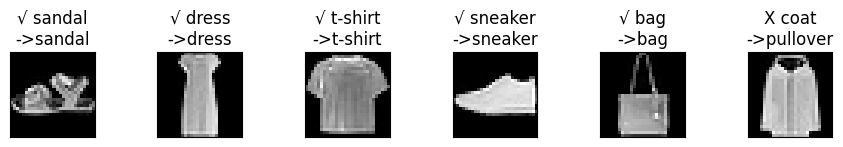

>>> 成功展示了 6 张样本


In [26]:
visualizer.show_next(6)

## 4.4 模型选择、欠拟合与过拟合

> 在深度学习中，模型并不是越复杂越好，我们的终极目标不是让模型在训练集上拿满分，而是让它在没见过的数据上表现良好。这种能力叫做泛化（Generalization）。

### 1. 核心概念梳理

在进入代码实验前，我们需要统一三个核心术语的数学直觉：

#### (1) 训练误差 vs. 泛化误差
*   **训练误差 (Training Error)**：模型在训练数据集上的误差（相当于“开卷考试”的分数）。
*   **泛化误差 (Generalization Error)**：模型应用在同样分布但从未见过的新样本上的误差（相当于“正式考试”的分数）。
*   **工程目标**：我们通过最小化训练误差来拟合数据，但我们真正关心的是减小泛化误差。

#### (2) 欠拟合 (Underfitting)
*   **现象**：训练误差和验证误差都很高。
*   **本质**：模型太简单了（比如用直线去拟合曲线），连训练集里的规律都没学会。
*   **对策**：增加模型复杂度（加隐藏层、加神经元）。

#### (3) 过拟合 (Overfitting)
*   **现象**：训练误差极低，但验证误差极高。
*   **本质**：模型太复杂或训练太久，把训练集里的“噪声”和“随机干扰”当成规律背下来了。
*   **对策**：减少模型复杂度、增加数据量、使用正则化或丢弃法。

---

### 2. 实验设计：多项式回归

为了最直观地看到这三种状态，我们不再使用复杂的图像，而是回到最简单的**多项式回归**。
我们要拟合的真实公式是：
$$y = 5 + 1.2x - 3.4\frac{x^2}{2!} + 5.6\frac{x^3}{3!} + \epsilon$$

我们将尝试用不同阶数的模型去拟合它：
1.  **正常拟合**：用 3 阶多项式。
2.  **欠拟合**：强制只用 1 阶（线性）。
3.  **过拟合**：用 20 阶（极其复杂的模型）。

---


### 3. 实验代码实现

In [2]:
# 生成数据集
import math
import torch
from torch import nn, Tensor
import d2l_utils as d2l

def generate_poly_data(n_train: int = 100, n_test: int = 100) -> tuple[Tensor, Tensor, Tensor, Tensor]:
    """生成多项式数据集用于实验。
    
    真实模型: y = 5 + 1.2x -3.4(x^2/2!) + 5.6(x^3/3!) + noise

    Returns:
        tuple: (train_features, test_features, train_labels, test_labels)
    """
    max_degree = 20 # 多项式的最大阶数
    true_w = torch.zeros(max_degree) # 分配空间
    true_w[0:4] = torch.tensor([5, 1.2, -3.4, 5.6]) # 设定前4项系数

    # 生成随机 x, 形状为 (n_train + n_test, 1)
    features = torch.randn((n_train + n_test, 1))
    # 计算 x^0, x^1, x^2, ..., x^19
    # torch.pow(base, exponent): 计算 base^{exponent}
    poly_features = torch.pow(features, torch.arange(max_degree).float()) 
    # 归一化 (除以阶乘)，防止数值过大
    for i in range(max_degree):
        poly_features[:, i] /= math.gamma(i + 1)

    # 计算标签 y = Xw
    labels = torch.matmul(poly_features, true_w)
    labels += torch.normal(0, 0.1, size=labels.shape) # 加入噪声

    # 转换为列向量
    labels = labels.reshape((-1, 1))

    return (poly_features[:n_train, :], poly_features[n_train:, :],
            labels[:n_train, :], labels[n_train:, :])

# 获取数据
train_features, test_features, train_labels, test_labels = generate_poly_data()

In [5]:
import d2l_utils as d2l
from typing import Callable
from torch.utils import data
# 定义训练评估函数
def evaluate_loss(net: nn.Module, data_iter: torch.utils.data.DataLoader, loss_fn: Callable) -> float:
    """评估模型在给定数据集上的平均损失。
    
    Args:
        net: 神经网络模型。
        data_iter: 数据加载器。
        loss_fn: 损失函数（如 nn.MSELoss）。

    Returns:
        平均损失值。
    """
    if isinstance(net, nn.Module):
        net.eval() # 设置为评估模式

    metric = d2l.Accumulator(2) # [损失总和, 样本总数]
    for X, y in data_iter:
        y_hat = net(X)
        l = loss_fn(y_hat, y)
        metric.add(l.sum().item(), l.numel())
    return metric[0] / metric[1]

def train_poly(
    train_features: Tensor,
    test_features: Tensor,
    train_labels: Tensor,
    test_labels: Tensor,
    num_epochs: int = 400 
) -> tuple[float, float]:
    """多项式回归实验的训练逻辑封装。
    
    Args:
        train_features: 训练集特征。
        test_features: 测试集特征。
        train_labels: 训练集标签。
        test_labels: 测试集标签。
        num_epochs: 迭代轮数。

    Returns:
        (最终训练误差, 最终测试误差)。
    """
    loss_fn = nn.MSELoss(reduction='none')
    input_shape = train_features.shape[-1]

    # 定义简单的线性层作为模型
    net = nn.Sequential(nn.Linear(input_shape, 1, bias=False))
    batch_size = min(10, input_shape)

    train_iter = data.DataLoader(
        data.TensorDataset(train_features, train_labels),
        batch_size, shuffle=True
    )

    test_iter = data.DataLoader(
        data.TensorDataset(test_features, test_labels),
        batch_size, shuffle=False
    )

    trainer = torch.optim.SGD(net.parameters(), lr=0.01)

    for epoch in range(num_epochs):
        net.train()
        for X, y in train_iter:
            trainer.zero_grad()
            l = loss_fn(net(X), y)
            l.mean().backward()
            trainer.step()

    train_l = evaluate_loss(net, train_iter, loss_fn)
    test_l = evaluate_loss(net, test_iter, loss_fn)
    return train_l, test_l

### 三种情景实战

In [7]:
# --- 实验 1: 正常拟合 ---
# 我们只给模型前 4 个特征 (x^0 到 x^3)
l_train, l_test = train_poly(train_features[:, :4], test_features[:, :4], train_labels, test_labels)
print(f"[正常] 训练误差: {l_train:.4f}, 测试误差: {l_test:.4f}")

# --- 实验 2: 欠拟合 ---
# 真实规律是 3 阶，但我们只给模型 1 阶特征 (x^0, x^1)
l_train, l_test = train_poly(train_features[:, :2], test_features[:, :2], train_labels, test_labels)
print(f"[欠拟合] 训练误差: {l_train:.4f}, 测试误差: {l_test:.4f}")

# --- 实验 3: 过拟合 --- 
# 特征给足 20 阶，但训练样本只给 20 个（故意减少数据）
l_train, l_test = train_poly(train_features[:20, :], test_features[:20, :], train_labels[:20], test_labels[:20])
print(f"[过拟合] 训练误差: {l_train:.4f}, 测试误差: {l_test:.4f}")

[正常] 训练误差: 0.0082, 测试误差: 0.0117
[欠拟合] 训练误差: 4.7857, 测试误差: 28.6589
[过拟合] 训练误差: 0.3682, 测试误差: 0.2797


## 附录：超参数

在深度学习中，**超参数（Hyperparameters）** 是一个非常核心的概念。

简单一句话总结：**“参数”是模型自己通过学习（反向传播）算出来的；而“超参数”是你（程序员）在训练开始前手动设定好的。**

---

### 1. 核心对比
*   **参数** ($w, b$)：模型**自己学**出来的（通过 `backward` 自动更新）。
*   **超参数**：你**帮模型选**的（决定模型怎么学、学多快）。

---

### 2. 深度对比：参数 vs. 超参数

| 特性 | 参数 (Parameters) | 超参数 (Hyperparameters) |
| :--- | :--- | :--- |
| **谁来决定** | **模型自己**通过数据学习 | **算法工程师**手动指定 |
| **何时确定** | 训练过程中不断更新 | 训练开始前就固定好 |
| **代表例子** | 权重 $w$、偏置 $b$ | 学习率、Batch Size、隐藏层神经元个数 |
| **存储位置** | `param.data` | 超参数通常出现在最顶层，作为全局配置（如 `lr = 0.1`） |
| **目标** | 最小化 Loss | 寻找最优的训练配置 |

---

### 3. 常见的超参数清单（本章涉及的）

| 超参数 | 含义 |
| :--- | :--- |
| **`lr`** (学习率) | 每次更新参数时迈的步子有多大。 |
| **`batch_size`** | 每次计算梯度时“看”多少张图片。 |
| **`num_epochs`** | 让模型把整套数据集从头到尾看几遍。 |
| **`num_hiddens`** | 隐藏层里放多少个神经元（模型的“脑容量”）。 |

---

### 4. 工程实践：如何调超参数？

寻找最优超参数的过程叫 **“调参” (Hyperparameter Tuning)**。在工业界，这通常有三种方法：
1.  **凭经验 (Intuition)**：比如 Fashion-MNIST 这种规模，`lr=0.1` 或 `0.01` 通常是安全的。
2.  **网格搜索 (Grid Search)**：尝试所有组合（比如 `lr` 选 [0.1, 0.01]，`batch_size` 选 [64, 128]，排列组合都试一遍）。
3.  **随机搜索 (Random Search)**：在一定范围内随机乱试（通常比网格搜索更高效）。

**一句话总结：参数决定“模型是什么”，超参数决定“模型怎么练”。**
